In [54]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay, classification_report, accuracy_score,\
    precision_score, recall_score, f1_score, roc_auc_score


### Step 3. Model Building, Step 4. Results and Evaluation
- Fit a model that predicts the outcome variable using two or more independent variables
- Check model assumptions
- Evaluate the model

### Identifying the type of Prediction Task

The goal is to predict whether an employee leaves the company, which is a categorical outcome variable. So this task involves classification. More specifically, this involves binary classification, since the outcome variable `left` can be either 1 (indicating employee left) or 0 (indicating employee didn't leave). 

Since the variable I want to predict (whether an employee leaves the company) is categorical, I could either build a Logistic Regression model, or a Tree-based Machine Learning model.

Let's go with Logistic Regression first.

There are two non-numeric variables, that needs to be taken care of (As ML only understands numbers): `department` and `salary`.

`department` is categorical which means I can dummy it.

`salary` is categorical too, but it is ordered i.e., it has hierarchy. So it's better not to dummy this column rather convert the level to numbers, 0-2.

In [55]:
#Load the cleaned and updated dataframe
df = pd.read_csv("HR_Attrition.csv")
df = df.drop(columns=(["Unnamed: 0"])) # An extra column I might have added while in Tableau
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11991 entries, 0 to 11990
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     11991 non-null  float64
 1   last_evaluation        11991 non-null  float64
 2   number_project         11991 non-null  int64  
 3   average_monthly_hours  11991 non-null  int64  
 4   tenure                 11991 non-null  int64  
 5   work_accident          11991 non-null  int64  
 6   left                   11991 non-null  int64  
 7   promotion_last_5years  11991 non-null  int64  
 8   department             11991 non-null  object 
 9   salary                 11991 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 936.9+ KB


In [56]:
#Copy the dataframe
df_enc = df.copy()

#Encode the salary column as an ordinal numeric category
df_enc["salary"] = (
    df_enc["salary"].astype("category")
    .cat.set_categories(["low","medium","high"])
    .cat.codes
)

#Dummy encode the department column
df_enc = pd.get_dummies(df_enc, drop_first=False)

df_enc.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


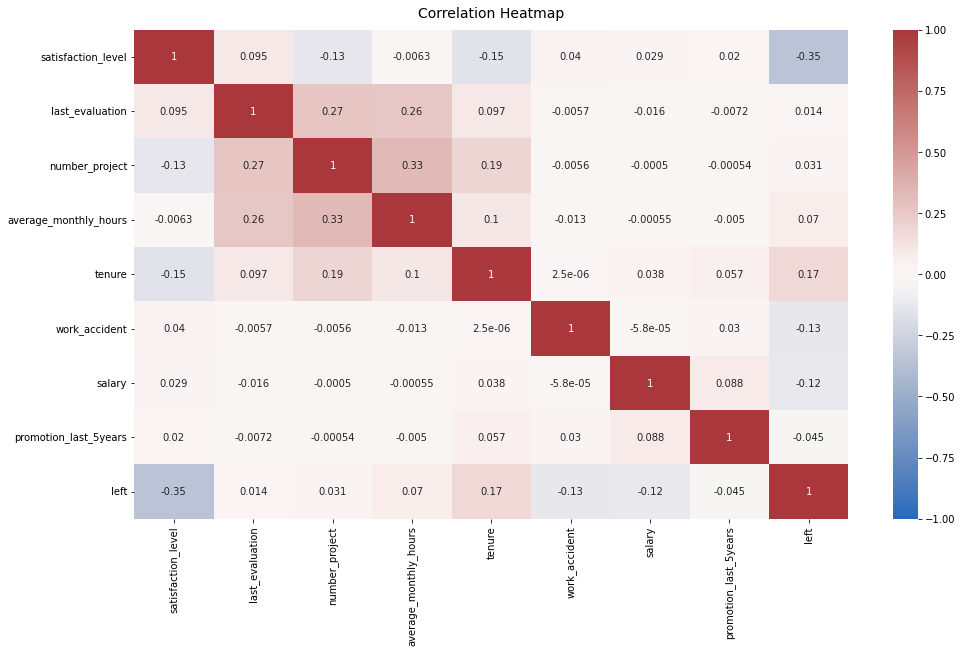

In [57]:
# Plot a correlation heatmap
plt.figure(figsize=(16, 9))
heatmap = sns.heatmap(df_enc[['satisfaction_level', 'last_evaluation', 'number_project', 'average_monthly_hours', 'tenure', 'work_accident', 'salary','promotion_last_5years', 'left']]
                      .corr(), vmin=-1, vmax=1, annot=True, cmap=sns.color_palette("vlag", as_cmap=True))
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':14}, pad=12);

The correlation heatmap confirms that the number of projects, monthly hours, and evaluation scores all have some positive correlation with each other, and whether an employee leaves is negatively correlated with their satisfaction level.

Since logistic regression is quite sensitive to outliers, it would be a good idea at this stage to remove the outliers in the `tenure` column that were identified earlier.

In [58]:
%store -r upper_limit
%store -r lower_limit

#Select rows without outliers in `tenure` and save resulting dataframe in a new variable
df_logreg = df_enc[(df_enc["tenure"] >= lower_limit) & df_enc["tenure"] <= upper_limit]

df_logreg.head()

,satisfaction_level,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.38,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.80,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.11,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.72,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.37,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


Choose the outcome variable and input variables

In [59]:
y = df_logreg["left"]
x = df_logreg.drop("left", axis=1)

Split the data into training set and testing set. We stratify based on the values in `y`, since the classes are unbalanced.

In [60]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y, random_state=42)

Construncting logistic regression model and fitting data

In [61]:
log_reg = LogisticRegression(random_state=42, max_iter=500).fit(x_train,y_train)

Test the model

In [62]:
y_pred = log_reg.predict(x_test)

Next we can create a confusion matrix to visualize the performance of the model

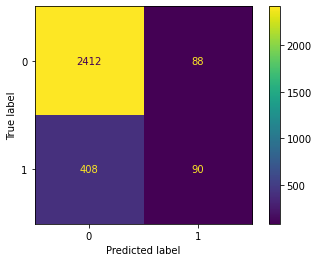

In [63]:
#Compute values for confusion matrix
log_cm = confusion_matrix(y_test,y_pred, labels = log_reg.classes_)

#Create display of confusion matrix
log_disp = ConfusionMatrixDisplay(confusion_matrix=log_cm, display_labels=log_reg.classes_)

#plot the matrix
log_disp.plot(values_format="")

plt.show()

The upper-left quadrant displays the number of true negatives.
The upper-right quadrant displays the number of false positives.
The bottom-left quadrant displays the number of false negatives.
The bottom-right quadrant displays the number of true positives.

True negatives: correctly predicted stay (0)

False positives: predicted leave but actually stayed

False negatives: predicted stay but actually left

True positives: correctly predicted leave (1)

A perfect model would yield all true negatives and true positives, and no false negatives or false positives.

Next step would be to create a classification report that includes precision, recall, f1-score, and accuracy metrics to evaluate the performance of the logistic regression model.

Checking the class balance in the data. In other words, check the value counts in the `left` column. Since this is a binary classification task, the class balance informs the way we interpret accuracy metrics.

In [64]:
df_logreg['left'].value_counts(normalize=True)

0    0.833959
1    0.166041
Name: left, dtype: float64

There is an approximately 83%-17% split. So the data is not perfectly balanced, but it is not too imbalanced. If it was more severely imbalanced, we might think to resample the data to make it more balanced. In this case, we can use this data without modifying the class balance and continue evaluating the model.

In [65]:
# Create classification report for logistic regression model
target_names = ['Predicted would not leave', 'Predicted would leave']
print(classification_report(y_test, y_pred, target_names=target_names))

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.96      0.91      2500
    Predicted would leave       0.51      0.18      0.27       498

                 accuracy                           0.83      2998
                macro avg       0.68      0.57      0.59      2998
             weighted avg       0.80      0.83      0.80      2998



Trying class weight = balanced method to improve recall. But no effect !

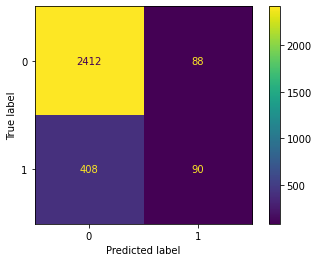

                           precision    recall  f1-score   support

Predicted would not leave       0.86      0.96      0.91      2500
    Predicted would leave       0.51      0.18      0.27       498

                 accuracy                           0.83      2998
                macro avg       0.68      0.57      0.59      2998
             weighted avg       0.80      0.83      0.80      2998



In [66]:
log_reg2 = LogisticRegression(random_state=42, class_weight="balanced", max_iter=500).fit(x_train,y_train)
y_pred2 = log_reg.predict(x_test)

#Compute values for confusion matrix
log_cm2 = confusion_matrix(y_test,y_pred2, labels = log_reg2.classes_)

#Create display of confusion matrix
log_disp2 = ConfusionMatrixDisplay(confusion_matrix=log_cm2, display_labels=log_reg2.classes_)

#plot the matrix
log_disp2.plot(values_format="")

plt.show()

print(classification_report(y_test, y_pred2, target_names=target_names))

## Modelling approach B - Tree Based Model

In [67]:
# Repeating the steps, because this time, we want to keep the "tenure" feature
y = df_enc['left']
X = df_enc.drop('left', axis=1)
# Split the data
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25, stratify=y, random_state=0)

Decision Tree - Round 1

Constructing a decision tree model and setting up cross-validated grid search for the best model parameters.

In [68]:
#Instantiate the classifier
tree = DecisionTreeClassifier(random_state=0)

#Assign a set of hyperparameters to search over
cv_params = {"max_depth":[4, 6, 8, None], #How deep the tree can grow
             "min_samples_leaf":[2, 5, 1], #Minimum number of samples required in a final leaf node
             "min_samples_split":[2,4,6]} #Minimum number of samples required to split a node
    
# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

#Instantiate Gridsearch
tree1 = GridSearchCV(tree, cv_params, scoring = scoring, cv = 4, refit = "roc_auc")
#cv - cross-validation (Splits data into 4 parts,Trains 4 times (each time different validation set)
#refit - After testing all models:Choose the best one based on ROC-AUC
#ROC-AUC - Area under ROC Curve

What we're trying to achieve in the above cell is try ALL combinations of cv_params and find best one.

In [69]:
%%time
tree1.fit(x_train,y_train)

Wall time: 5.2 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring={'accuracy', 'recall', 'roc_auc', 'f1', 'precision'})

In [70]:
#Check the best parameter
tree1.best_params_

{'max_depth': 4, 'min_samples_leaf': 5, 'min_samples_split': 2}

In [71]:
#Check the best AUC score
tree1.best_score_

0.969819392792457

This is a strong AUC score, which shows that this model can predict employees who will leave very well.


To Help with calculating score, we can write a function

In [72]:
def make_results(model_name:str, model_object, metric:str):
    '''
    Arguments:
        model_name (string): what you want the model to be called in the output table
        model_object: a fit GridSearchCV object
        metric (string): precision, recall, f1, accuracy, or auc
  
    Returns a pandas df with the F1, recall, precision, accuracy, and auc scores
    for the model with the best mean 'metric' score across all validation folds.  
    '''

    # Create dictionary that maps input metric to actual metric name in GridSearchCV
    metric_dict = {'auc': 'mean_test_roc_auc',
                   'precision': 'mean_test_precision',
                   'recall': 'mean_test_recall',
                   'f1': 'mean_test_f1',
                   'accuracy': 'mean_test_accuracy'
                  }

    # Get all the results from the CV and put them in a df
    cv_results = pd.DataFrame(model_object.cv_results_)

    # Isolate the row of the df with the max(metric) score
    best_estimator_results = cv_results.iloc[cv_results[metric_dict[metric]].idxmax(), :]

    # Extract Accuracy, precision, recall, and f1 score from that row
    auc = best_estimator_results.mean_test_roc_auc
    f1 = best_estimator_results.mean_test_f1
    recall = best_estimator_results.mean_test_recall
    precision = best_estimator_results.mean_test_precision
    accuracy = best_estimator_results.mean_test_accuracy
  
    # Create table of results
    table = pd.DataFrame()
    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision],
                          'recall': [recall],
                          'F1': [f1],
                          'accuracy': [accuracy],
                          'auc': [auc]
                        })
  
    return table

In [73]:
# Get all CV scores
tree1_cv_results = make_results('decision tree cv', tree1, 'auc')
tree1_cv_results

,model,precision,recall,F1,accuracy,auc
0,decision tree cv,0.914552,0.916949,0.915707,0.971978,0.969819


All these scores are solid indicators that this is a good model. But decision tree is vulnerable to overfitting/bias. Hence we go towards random forest that is good at overcoming these shortcomings by incorporating multiple trees.

Random Forest - Round 1

In [74]:
# Instantiate the model
rf = RandomForestClassifier(random_state=0, n_jobs= -1)

#Assign a dict of hyperparameters to search over
cv_params = {'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 0.99],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500],
             }

# Assign a dictionary of scoring metrics to capture
scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

#Instantiate grid search
rf1 = GridSearchCV(rf, cv_params, scoring= scoring, cv= 4, refit= "roc_auc", n_jobs= 1)

In [75]:
# %%time
# rf1.fit(x_train, y_train) #-->Wall time: 16min 8s

In [76]:
# joblib.dump(rf1,"hr_rf1.joblib") #Save one time

In [77]:
rf1 = joblib.load("hr_rf1.joblib")

In [78]:
# Checking best AUC score on CV
rf1.best_score_

0.9804250949807172

In [79]:
# Checking best params
rf1.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.7,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

Compare the two models side by side

In [80]:
# Get all CV scores
rf1_cv_results = make_results('random forest cv', rf1, 'auc')
print(tree1_cv_results)
print(rf1_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
              model  precision    recall        F1  accuracy       auc
0  random forest cv   0.950023  0.915614  0.932467  0.977983  0.980425


Random forest outperforms decision tree.

Next we evaluate the final model on our test set

In [81]:
# Write a function to get all the scores from model's prediction
def get_scores(model_name:str, model, X_test_data, y_test_data):
    '''
    Generate a table of test scores.

    In: 
        model_name (string):  How you want your model to be named in the output table
        model:                A fit GridSearchCV object
        X_test_data:          numpy array of X_test data
        y_test_data:          numpy array of y_test data

    Out: pandas df of precision, recall, f1, accuracy, and AUC scores for your model
    '''

    preds = model.best_estimator_.predict(X_test_data)

    auc = roc_auc_score(y_test_data, preds)
    accuracy = accuracy_score(y_test_data, preds)
    precision = precision_score(y_test_data, preds)
    recall = recall_score(y_test_data, preds)
    f1 = f1_score(y_test_data, preds)

    table = pd.DataFrame({'model': [model_name],
                          'precision': [precision], 
                          'recall': [recall],
                          'f1': [f1],
                          'accuracy': [accuracy],
                          'AUC': [auc]
                         })
  
    return table

In [82]:
# Get predictions on test data
rf1_test_scores = get_scores('random forest1 test', rf1, x_test, y_test)
rf1_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest1 test,0.964211,0.919679,0.941418,0.980987,0.956439


The test scores are very similar to the validation scores, which is good. This appears to be a strong model. Since this test set was only used for this model, we can be more confident that our model's performance on this data is representative of how it will perform on new, unseeen data.

## Feature Engineering

One might be skeptical of the high evaluation scores. There is a chance that there is some data leakage occurring. Data leakage is when we use data to train a model that should not be used during training, either because it appears in the test data or because it's not data that you'd expect to have when the model is actually deployed. Training a model with leaked data can give an unrealistic score that is not replicated in production.

- Example 1: `satisfaction_level`,
Why risky?

Comes from surveys, Not always available for all employees


So, Model learns something you won’t have in production

- Example 2: `average_montly_hours`
Why risky?

If, Employee already decided to quit Or is being fired


Then, their working hours change BECAUSE they are leaving

That’s, effect of leaving, not cause !

Let's proceed by dropping `satisfaction_level` and creating a new feature that roughly captures whether an employee is overworked. We call this new feature `overworked`. It will be a binary variable.

In [30]:
df2 = df_enc.drop('satisfaction_level', axis=1)

df2.head()

,last_evaluation,number_project,average_monthly_hours,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical
0,0.53,2,157,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0
1,0.86,5,262,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0
2,0.88,7,272,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0
3,0.87,5,223,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0
4,0.52,2,159,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0


166.67 is approximately the average number of monthly hours for someone who works 50 weeks per year, 5 days per week, 8 hours per day. 

Let's define being overworked as working more than 175 hours per month on average.

In [31]:
# Define `overworked` as working > 175 hrs/week
df2['overworked'] = (df2['average_monthly_hours'] > 175).astype(int)

df2['overworked'].head()

0    0
1    1
2    1
3    1
4    0
Name: overworked, dtype: int32

In [32]:
# Drop the `average_monthly_hours` column
df2 = df2.drop('average_monthly_hours', axis=1)

df2.head()

,last_evaluation,number_project,tenure,work_accident,left,promotion_last_5years,salary,department_IT,department_RandD,department_accounting,department_hr,department_management,department_marketing,department_product_mng,department_sales,department_support,department_technical,overworked
0,0.53,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0
1,0.86,5,6,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
2,0.88,7,4,0,1,0,1,0,0,0,0,0,0,0,1,0,0,1
3,0.87,5,5,0,1,0,0,0,0,0,0,0,0,0,1,0,0,1
4,0.52,2,3,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0


In [33]:
# Isolate the outcome variable
y = df2['left']

# Select the features
x = df2.drop('left', axis=1)

In [34]:
# Train-Test split
x_train, x_test, y_train, y_test = train_test_split(x, y, stratify= y, random_state= 0)


### Decision Tree - Round 2

In [35]:
tree = DecisionTreeClassifier(random_state=0)

cv_params = {
    "max_depth":[4, 6, 8, None],
    "min_samples_leaf":[2, 5, 1],
    "min_samples_split":[2, 4, 6]                    
}

scoring = {'accuracy', 'precision', 'recall', 'f1', 'roc_auc'}

tree2 = GridSearchCV(tree, cv_params, scoring= scoring, cv= 4, refit= "roc_auc")

In [36]:
%%time
tree2.fit(x_train, y_train)

Wall time: 5.88 s


GridSearchCV(cv=4, estimator=DecisionTreeClassifier(random_state=0),
             param_grid={'max_depth': [4, 6, 8, None],
                         'min_samples_leaf': [2, 5, 1],
                         'min_samples_split': [2, 4, 6]},
             refit='roc_auc',
             scoring={'accuracy', 'recall', 'roc_auc', 'f1', 'precision'})

In [37]:
tree2.best_params_

{'max_depth': 6, 'min_samples_leaf': 2, 'min_samples_split': 6}

In [38]:
tree2.best_score_

0.9586752505340426

This model performs very well, even without satisfaction levels and detailed hours worked data. 

Next, compare with the model with all the features

In [39]:
tree2_cv_results = make_results("decision tree2 cv", tree2, "auc")
print(tree1_cv_results)
print(tree2_cv_results)

              model  precision    recall        F1  accuracy       auc
0  decision tree cv   0.914552  0.916949  0.915707  0.971978  0.969819
               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675


Some of the other scores fell. That's to be expected given fewer features were taken into account in this round of the model. Still, the scores are very good.

## Random Forest - Round 2

In [40]:
rf = RandomForestClassifier(random_state= 0, n_jobs= -1)

cv_params = {
             'max_depth': [3,5, None], 
             'max_features': [1.0],
             'max_samples': [0.7, 0.99],
             'min_samples_leaf': [1,2,3],
             'min_samples_split': [2,3,4],
             'n_estimators': [300, 500]
            }

scoring = {"accuracy", "precision", "recall", "f1", "roc_auc"}

rf2 = GridSearchCV(rf, cv_params, scoring= scoring, cv= 4, refit= "roc_auc", n_jobs= 1)

In [ ]:
# %%time
# rf2.fit(x_train, y_train) #-->Wall time 14min 11s

Wall time: 14min 11s


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=0),
             n_jobs=1,
             param_grid={'max_depth': [3, 5, None], 'max_features': [1.0],
                         'max_samples': [0.7, 0.99],
                         'min_samples_leaf': [1, 2, 3],
                         'min_samples_split': [2, 3, 4],
                         'n_estimators': [300, 500]},
             refit='roc_auc',
             scoring={'accuracy', 'recall', 'roc_auc', 'f1', 'precision'})

In [ ]:
# joblib.dump(rf2,"hr_rf2.joblib")

['hr_rf2.joblib']

In [43]:
rf2 = joblib.load("hr_rf2.joblib")

In [44]:
rf2.best_params_

{'max_depth': 5,
 'max_features': 1.0,
 'max_samples': 0.99,
 'min_samples_leaf': 1,
 'min_samples_split': 4,
 'n_estimators': 500}

In [45]:
rf2.best_score_

0.9648566065958433

Compare two round 2 models

In [46]:
rf2_cv_results = make_results("random forest2 cv", rf2, "auc")
print(tree2_cv_results)
print(rf2_cv_results)

               model  precision    recall        F1  accuracy       auc
0  decision tree2 cv   0.856693  0.903553  0.878882  0.958523  0.958675
               model  precision    recall        F1  accuracy       auc
0  random forest2 cv    0.86624  0.879426  0.872514  0.957411  0.964857


Again, the scores dropped slightly, but the random forest performs better than the decision tree if using AUC as the deciding metric. 

Score the champion model on the test set now.

In [47]:
rf2_test_scores = get_scores("random forest2 test", rf2, x_test, y_test)
rf2_test_scores

,model,precision,recall,f1,accuracy,AUC
0,random forest2 test,0.871154,0.909639,0.88998,0.962642,0.941419


This seems to be a stable, well-performing final model. 

Let us now again visualize the performance using confusion matrix

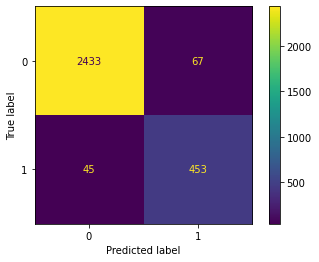

In [48]:
preds = rf2.best_estimator_.predict(x_test)
cm = confusion_matrix(y_test, preds, labels= rf2.classes_)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels= rf2.classes_)

disp.plot(values_format="")

The model predicts more false positives than false negatives, which means that some employees may be identified as at risk of quitting or getting fired, when that's actually not the case. But this is still a strong model.

For exploratory purpose, we might want to inspect the splits of the decision tree model and the most important features in the random forest model. 

### Decision Tree Splits

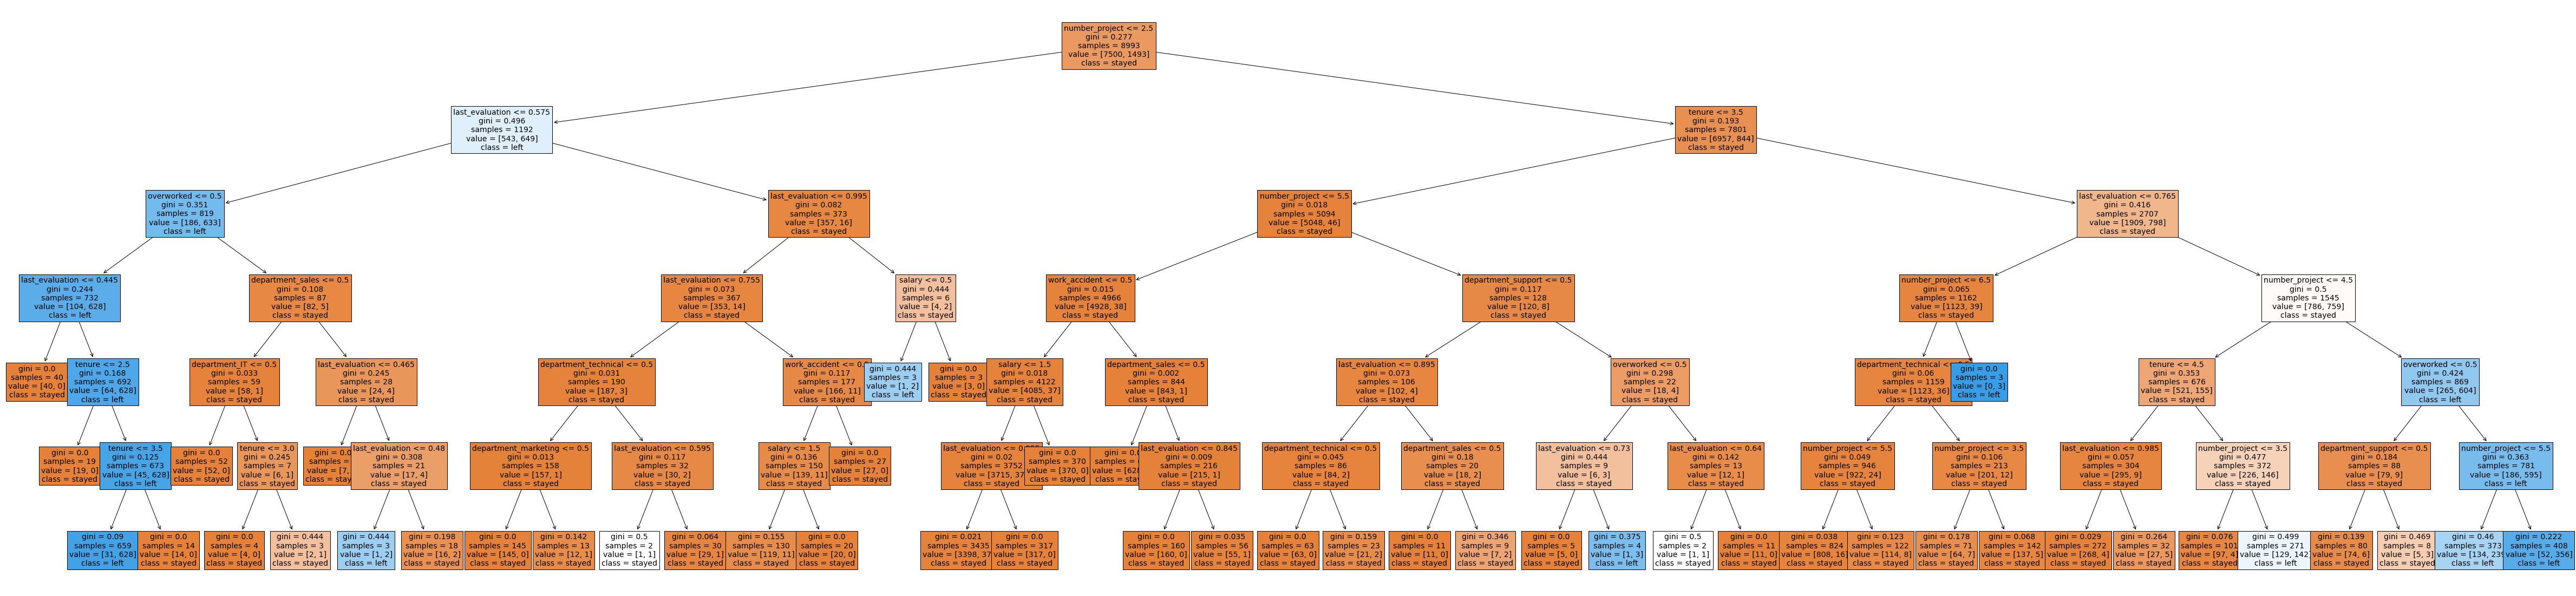

In [49]:
# Plot the tree
plt.figure(figsize=(85,20))
plot_tree(tree2.best_estimator_, max_depth=6, fontsize=14, feature_names=x.columns, 
          class_names={0:'stayed', 1:'left'}, filled=True);
plt.show()

Decision Tree Feature importance

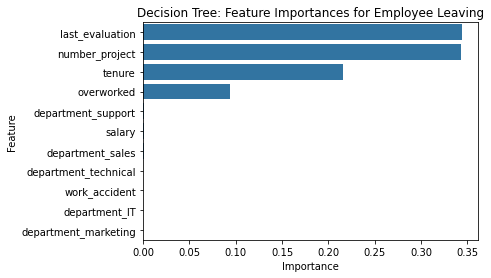

In [50]:
tree2_importances = pd.DataFrame(tree2.best_estimator_.feature_importances_, 
                                 columns=['gini_importance'], 
                                 index=x.columns
                                )
tree2_importances = tree2_importances.sort_values(by='gini_importance', ascending=False)

# Only extract the features with importances > 0
tree2_importances = tree2_importances[tree2_importances['gini_importance'] != 0]

#Plot a bar graph
sns.barplot(data=tree2_importances, x="gini_importance", y=tree2_importances.index, orient='h')
plt.title("Decision Tree: Feature Importances for Employee Leaving", fontsize=12)
plt.ylabel("Feature")
plt.xlabel("Importance")
plt.show()

The barplot above shows that in this decision tree model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`.

Random Forest Feature Importance

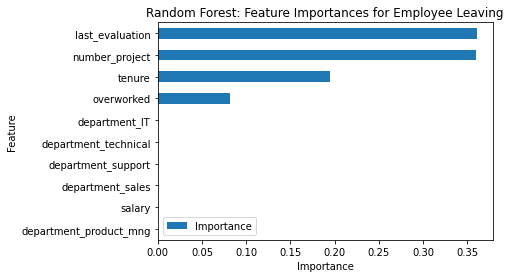

In [51]:
# Get feature importances
feat_impt = rf2.best_estimator_.feature_importances_

# Get indices of top 10 features
ind = np.argpartition(rf2.best_estimator_.feature_importances_, -10)[-10:]

# Get column labels of top 10 features 
feat = x.columns[ind]

# Filter `feat_impt` to consist of top 10 feature importances
feat_impt = feat_impt[ind]

y_df = pd.DataFrame({"Feature":feat,"Importance":feat_impt})
y_sort_df = y_df.sort_values("Importance")
fig = plt.figure()
ax1 = fig.add_subplot(111)

y_sort_df.plot(kind='barh',ax=ax1,x="Feature",y="Importance")

ax1.set_title("Random Forest: Feature Importances for Employee Leaving", fontsize=12)
ax1.set_ylabel("Feature")
ax1.set_xlabel("Importance")

plt.show()

The plot above shows that in this random forest model, `last_evaluation`, `number_project`, `tenure`, and `overworked` have the highest importance, in that order. These variables are most helpful in predicting the outcome variable, `left`, and they are the same as the ones used by the decision tree model.

### Summary of model results

**Logistic Regression**

The logistic regression model achieved precision of 80%, recall of 83%, f1-score of 80% (all weighted averages), and accuracy of 83%, on the test set.

**Tree-based Machine Learning**

After conducting feature engineering, the decision tree model achieved AUC of 95.9%, precision of 85.7%, recall of 90.3%, f1-score of 87.9%, and accuracy of 95.8%, on the test set. The random forest modestly outperformed the decision tree model. 

### Conclusion

The models and the feature importances extracted from the models confirm that employees at the company are overworked. 

To retain employees, the following recommendations could be presented to the stakeholders:

* Cap the number of projects that employees can work on.
* Consider promoting employees who have been with the company for atleast four years, or conduct further investigation about why four-year tenured employees are so dissatisfied. 
* Either reward employees for working longer hours, or don't require them to do so. 
* If employees aren't familiar with the company's overtime pay policies, inform them about this. If the expectations around workload and time off aren't explicit, make them clear. 
* Hold company-wide and within-team discussions to understand and address the company work culture, across the board and in specific contexts. 
* High evaluation scores should not be reserved for employees who work 200+ hours per month. Consider a proportionate scale for rewarding employees who contribute more/put in more effort. 